In [23]:
from google.colab import files

uploaded = files.upload()

Saving clean_population_data.csv to clean_population_data.csv


In [24]:
import os
print(os.listdir())

['.config', 'clean_population_data.csv', 'sample_data']


In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load the cleaned CSV
df = pd.read_csv("clean_population_data.csv")

# Connect to SQLite (no installation required)
conn = sqlite3.connect("population_data.db")

# Push data to SQLite
df.to_sql("population_data", conn, index=False, if_exists="replace")

217

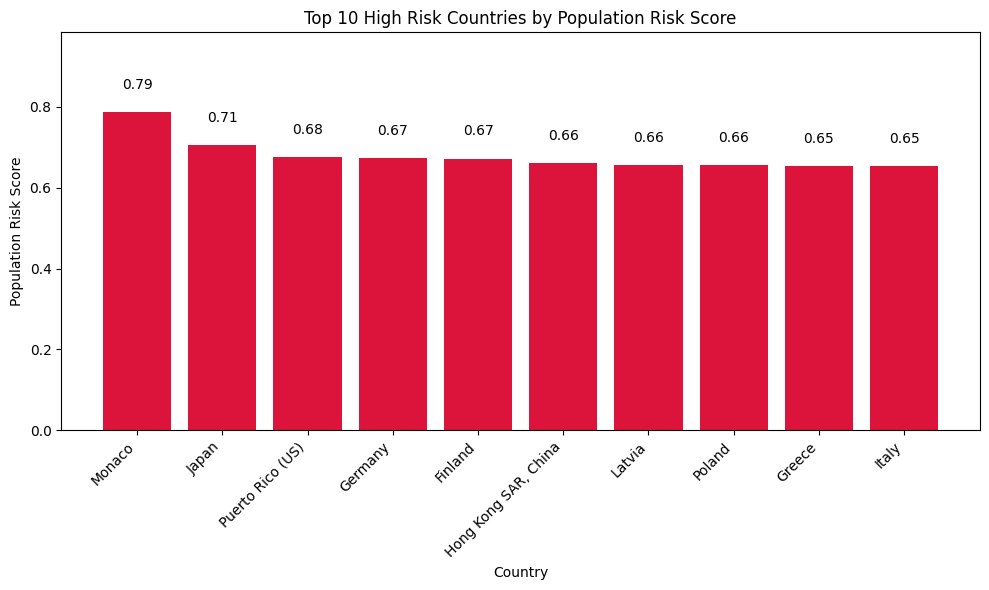

In [27]:
# Top 10 countries with the highest risk
High_Risk_Countries = """
SELECT country, population_risk_score
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;
"""
top_risk = pd.read_sql_query(High_Risk_Countries, conn)

# Make the bar chart
plt.figure(figsize=(10,6))
plt.bar(top_risk['country'], top_risk['population_risk_score'], color='crimson')

# Add labels and title
plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 High Risk Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, top_risk['population_risk_score'].max() * 1.25)

# Optional: add value labels on top of bars
for i, score in enumerate(top_risk['population_risk_score']):
    plt.text(i, score + 0.05, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

The countries with the highest population risk scores tend to have a combination of:
- Low fertility rates
- High dependency ratios
- Negative net migration

This indicates they are at risk of population decline over the coming years.

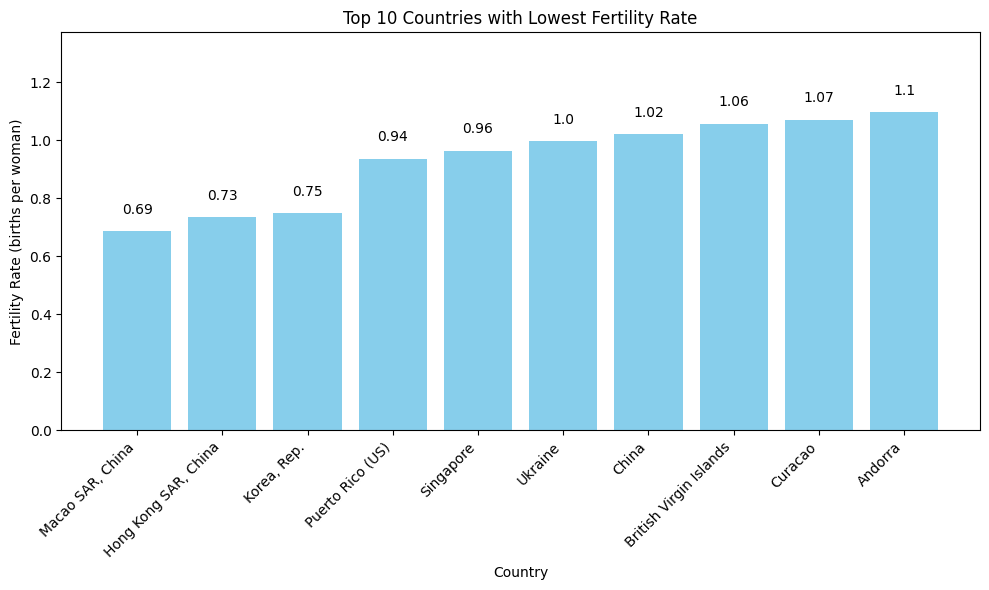

In [28]:
Low_Fertility_Rate = """SELECT country, fertility_rate
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;
"""
Low_fertility = pd.read_sql_query(Low_Fertility_Rate, conn)

# Bar chart for the 10 countries with lowest fertility rates
plt.figure(figsize=(10,6))
plt.bar(Low_fertility['country'], Low_fertility['fertility_rate'], color='skyblue')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries with Lowest Fertility Rate")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, Low_fertility['fertility_rate'].min() * 2)

# Add values on top of each bar
for i, rate in enumerate(Low_fertility['fertility_rate']):
    plt.text(i, rate + 0.05, round(rate, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [36]:
Count_Low_Fertility_Rate = """SELECT COUNT(*) AS count_low_fertility
FROM population_data
WHERE fertility_rate < 2.1
ORDER BY fertility_rate ASC"""

Count_Low_fertility = pd.read_sql_query(Count_Low_Fertility_Rate, conn)
print(Count_Low_fertility)



   count_low_fertility
0                  121


Fertility Rates Insight

Out of the countries in the dataset, 121 have fertility rates below the replacement level of 2.1 births per woman.

This indicates that a large portion of countries may face population decline in the long term if not offset by migration.

Combined with high dependency ratios in some countries, this could lead to aging populations and economic pressure.

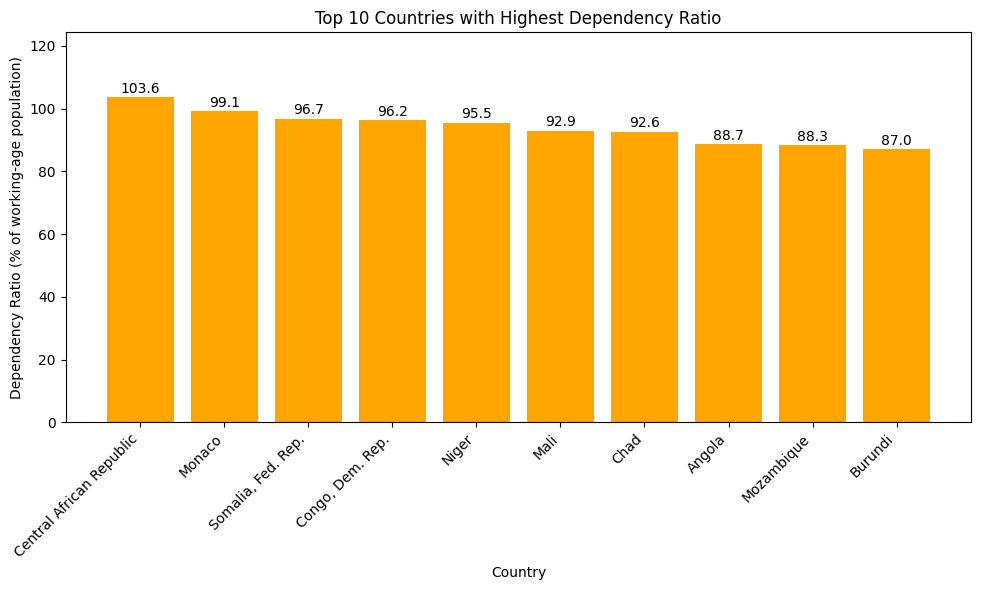

In [29]:
High_Dependency_Ratio = """SELECT country, dependency_ratio
FROM population_data
ORDER BY dependency_ratio DESC
LIMIT 10
"""

High_dependency = pd.read_sql_query(High_Dependency_Ratio, conn)

# Bar chart for countries with highest dependency ratio
plt.figure(figsize=(10,6))
plt.bar(High_dependency['country'], High_dependency['dependency_ratio'], color='orange')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Dependency Ratio (% of working-age population)")
plt.title("Top 10 Countries with Highest Dependency Ratio")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, High_dependency['dependency_ratio'].max() * 1.2)

# Add values on top of bars
for i, ratio in enumerate(High_dependency['dependency_ratio']):
    plt.text(i, ratio + 0.5, round(ratio, 1), ha='center', va='bottom')

plt.tight_layout()
plt.show()

A dependency ratio measure the number of people of non-working age to the number of people who are of working-age.

The Central African Republic is the only country that has more people of non-working age than people of working age, which is largely due to their high fertitlity rate of 5.9 per woman.

The countries with the highest dependency ratios are all located in Africa, reflecting their high birth-rates and young populations.

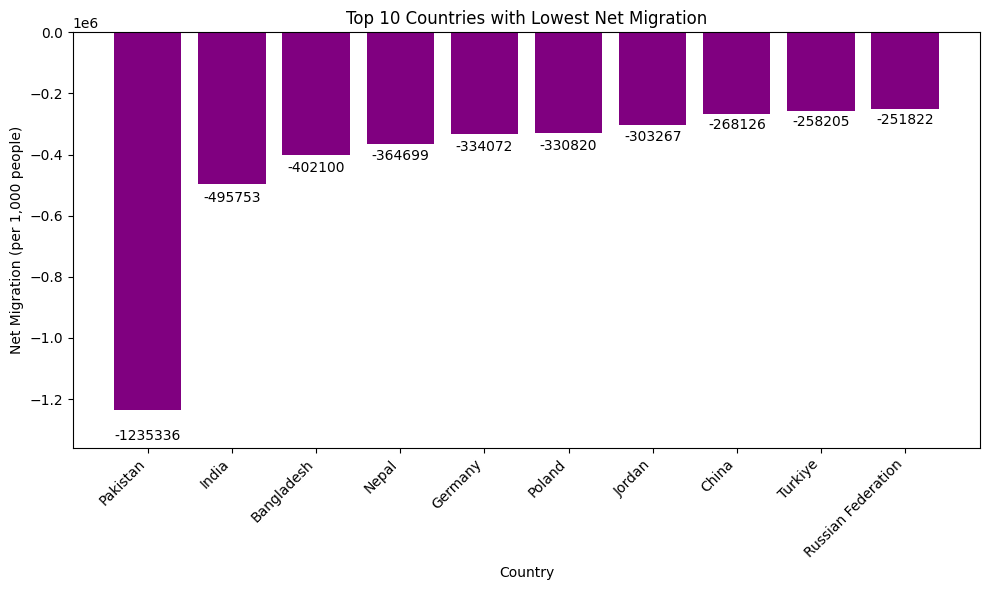

In [30]:
Low_migration = """SELECT country, net_migration
FROM population_data
WHERE net_migration < 0
ORDER BY net_migration ASC
LIMIT 10"""

low_migration = pd.read_sql_query(Low_migration, conn)

# Bar chart for countries with lowest net migration
plt.figure(figsize=(10,6))
plt.bar(low_migration['country'], low_migration['net_migration'], color='purple')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Net Migration (per 1,000 people)")
plt.title("Top 10 Countries with Lowest Net Migration")
plt.xticks(rotation=45, ha='right')
plt.ylim(low_migration['net_migration'].min() * 1.1, 0.5)

for i, val in enumerate(low_migration['net_migration']):
    # offset = 5% of the bar height (scales automatically)
    offset = abs(val) * 0.05
    plt.text(i, val - offset, round(val, 1), ha='center', va='top')

plt.tight_layout()
plt.show()

In [31]:
average_population_risk = """
SELECT AVG(population_risk_score) AS average_risk
FROM population_data

"""
average_population_risk = pd.read_sql_query(average_population_risk, conn)

print(average_population_risk)

   average_risk
0      0.569016


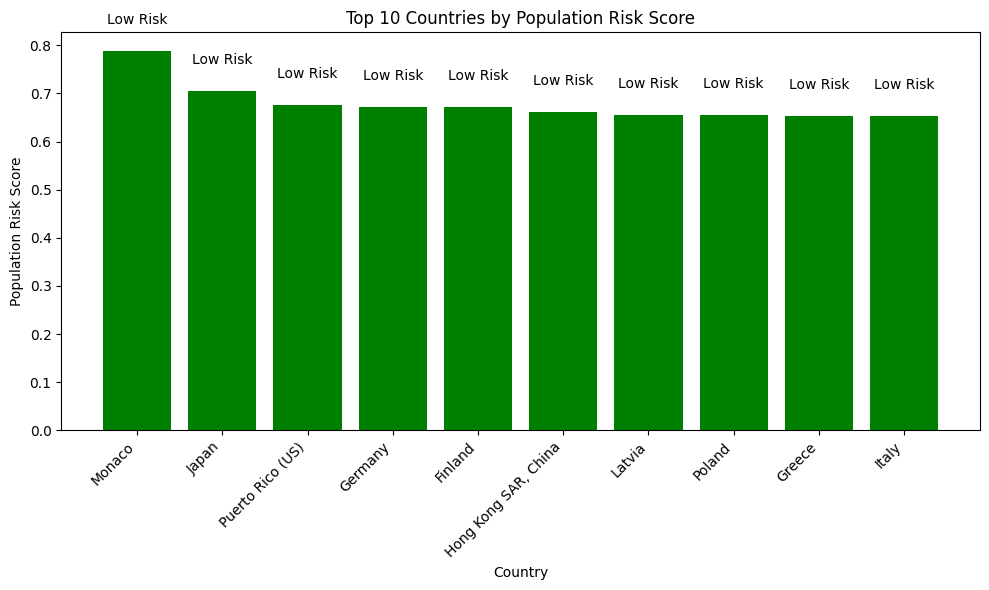

In [32]:
risk_score_categorization = """SELECT country,
       dependency_ratio,
       fertility_rate,
       net_migration,
       population_risk_score,
       CASE
           WHEN population_risk_score >= 2 THEN 'High Risk'
           WHEN population_risk_score >= 1.5 THEN 'Medium Risk'
           ELSE 'Low Risk'
       END AS risk_level
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

risk_score_categorization = pd.read_sql_query(risk_score_categorization, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
colors = {'High Risk':'red', 'Medium Risk':'orange', 'Low Risk':'green'}

plt.bar(risk_score_categorization['country'],
        risk_score_categorization['population_risk_score'],
        color=[colors[level] for level in risk_score_categorization['risk_level']])

plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')

# Add risk level labels above each bar
for i, score in enumerate(risk_score_categorization['population_risk_score']):
    plt.text(i, score + 0.05, risk_score_categorization['risk_level'][i], ha='center', va='bottom')

plt.tight_layout()
plt.show()


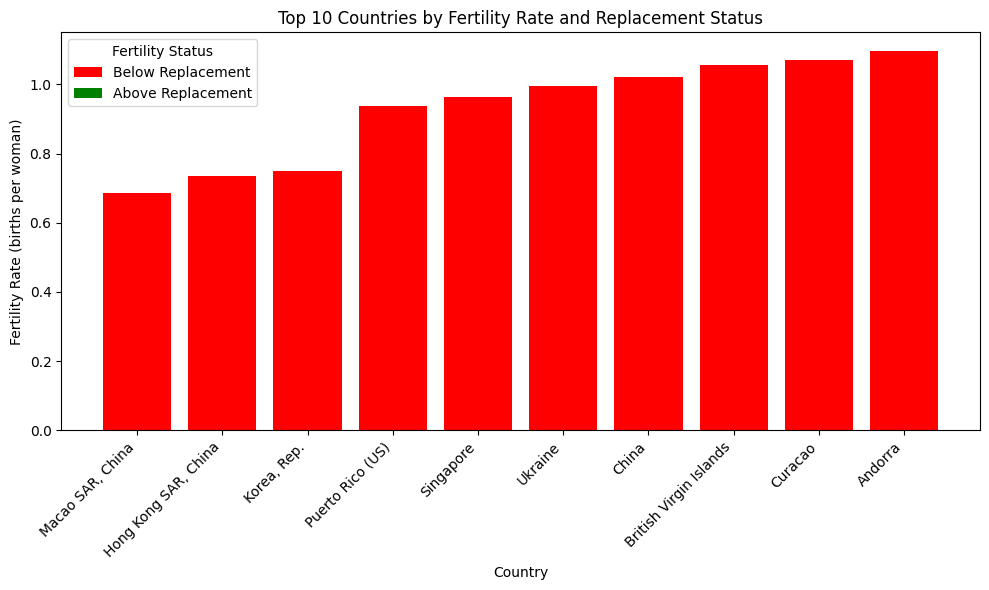

In [33]:
fertility_replacement = """SELECT country,
       fertility_rate,
       CASE WHEN fertility_rate < 2.1 THEN 'Below Replacement' ELSE 'Above Replacement' END AS fertility_status
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;"""

fertility_replacement = pd.read_sql_query(fertility_replacement, conn)
from matplotlib.patches import Patch
# Set colors by status
colors = {'Below Replacement':'red', 'Above Replacement':'green'}

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(fertility_replacement['country'], fertility_replacement['fertility_rate'],
        color=[colors[status] for status in fertility_replacement['fertility_status']])

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries by Fertility Rate and Replacement Status")
plt.xticks(rotation=45, ha='right')
legend_elements = [Patch(facecolor=color, label=label) for label, color in colors.items()]
plt.legend(handles=legend_elements, title="Fertility Status")


plt.tight_layout()
plt.show()

In [34]:
largest_risk = """SELECT country,
       CASE
           WHEN dependency_ratio >= 60 THEN 'Dependency is main risk'
           WHEN fertility_rate < 2.1 THEN 'Low fertility is main risk'
           WHEN net_migration < 0 THEN 'Migration is main risk'
           ELSE 'No single factor dominates'
       END AS main_risk_factor
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

largest_risk = pd.read_sql_query(largest_risk, conn)

print(largest_risk)

                country            main_risk_factor
0                Monaco     Dependency is main risk
1                 Japan     Dependency is main risk
2      Puerto Rico (US)  Low fertility is main risk
3               Germany     Dependency is main risk
4               Finland     Dependency is main risk
5  Hong Kong SAR, China  Low fertility is main risk
6                Latvia  Low fertility is main risk
7                Poland  Low fertility is main risk
8                Greece  Low fertility is main risk
9                 Italy  Low fertility is main risk
